
# Traffic Congestion Predictor

## Exploratory Data Analysis (EDA)

### Objective

### Research Questions


In [ ]:

1. How many rows and columns are in the dataset?
2. Are there missing values?
3. Are there duplicate records?
4. What is the distribution of congestion classes?
5. What is the average vehicle speed?
6. What are the peak traffic hours?
7. What are the rush hour patterns?

### Import library

In [2]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

### Load Dataset


In [47]:
import pandas as pd

DATA_PATH = "../../dataset/raw/nigerian_transport_and_logistics_traffic_flow.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,timestamp,segment_id,lat,lon,hour,avg_speed_kmh,density_veh_per_km,incidents,congestion_index
0,2024-12-16 14:39:24,SEG-0162239,6.863982,13.298207,14,95.3,23.1,1,20.6
1,2025-03-01 15:41:09,SEG-0117236,6.969183,14.701078,15,92.3,36.0,0,23.1
2,2024-11-16 11:28:45,SEG-0024260,4.801158,2.687999,11,51.9,32.1,0,42.4
3,2025-06-11 11:54:33,SEG-0093490,4.871314,8.517009,11,54.6,38.8,1,9.0
4,2024-12-28 07:33:06,SEG-0162248,6.062270,10.121534,7,29.6,55.4,0,67.1


### Dataset Overview

In [72]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

rows, cols = df.shape

print(f"Rows    : {rows:,}")
print(f"Columns : {cols}")

DATASET OVERVIEW
Rows    : 180,000
Columns : 10


### Dataset Shape

In [48]:
rows, cols = df.shape

print("="*40)
print("DATASET SHAPE")
print("="*40)

print(f"Rows    : {rows:,}")
print(f"Columns : {cols}")

DATASET SHAPE
Rows    : 180,000
Columns : 9


### Dataset information

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   timestamp           180000 non-null  object 
 1   segment_id          180000 non-null  object 
 2   lat                 180000 non-null  float64
 3   lon                 180000 non-null  float64
 4   hour                180000 non-null  int64  
 5   avg_speed_kmh       180000 non-null  float64
 6   density_veh_per_km  180000 non-null  float64
 7   incidents           180000 non-null  int64  
 8   congestion_index    180000 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 12.4+ MB


## Findings

Record the columns with missing values (if any).

If there are no missing values, state that the dataset is complete.

In [50]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,180000,179478,2025-01-02 19:08:59,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment_id,180000,118941,SEG-0199223,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,180000.0,NaN,NaN,NaN,9.053156,2.801821,4.174715,6.625387,9.063399,11.484441,13.925514
lon,180000.0,NaN,NaN,NaN,8.690853,3.457842,2.682127,5.706067,8.690037,11.680738,14.725056
hour,180000.0,NaN,NaN,NaN,11.502689,6.917779,0.0,6.0,12.0,17.0,23.0
avg_speed_kmh,180000.0,NaN,NaN,NaN,55.827961,21.218505,5.0,40.2,54.8,70.6,120.0
density_veh_per_km,180000.0,NaN,NaN,NaN,46.290777,20.862532,2.0,31.8,46.1,60.5,135.5
incidents,180000.0,NaN,NaN,NaN,0.149356,0.392944,0.0,0.0,0.0,0.0,4.0
congestion_index,180000.0,NaN,NaN,NaN,37.988106,17.311724,0.0,26.3,38.0,49.5,94.4


### Missing Value

In [51]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": round(df.isnull().mean()*100,2)
})

missing

,Missing Values,Percentage (%)
timestamp,0,0.0
segment_id,0,0.0
lat,0,0.0
lon,0,0.0
hour,0,0.0
avg_speed_kmh,0,0.0
density_veh_per_km,0,0.0
incidents,0,0.0
congestion_index,0,0.0


### Visualization

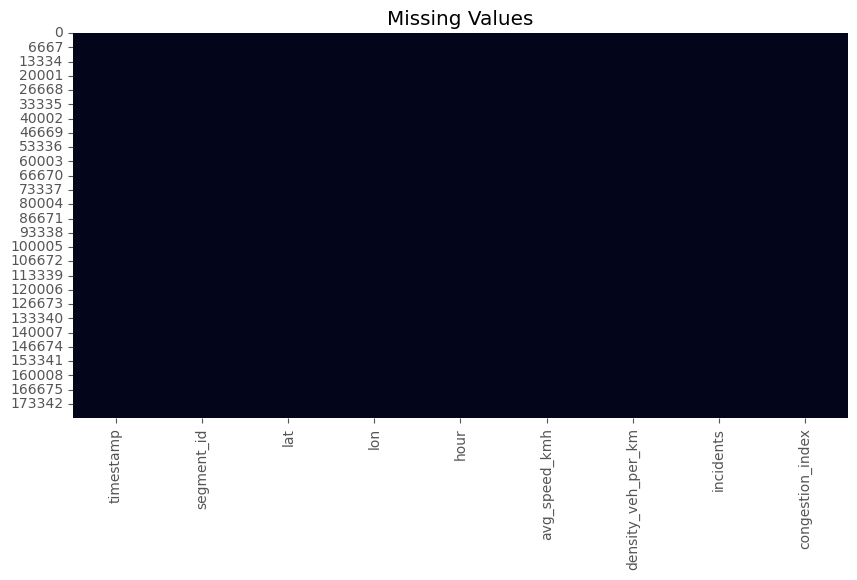

In [52]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

## Findings

Document the number of duplicate records removed (if any).

In [53]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


### Remove duplicate

In [54]:
df = df.drop_duplicates()

## Findings

Identify which congestion class occurs most frequently.

Discuss whether the dataset appears balanced or imbalanced.

 Convert Timestamp

In [74]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["date"] = df["timestamp"].dt.date

df["month"] = df["timestamp"].dt.month_name()

df["day"] = df["timestamp"].dt.day_name()

Verify

In [75]:
df.head()

,timestamp,segment_id,lat,lon,hour,avg_speed_kmh,density_veh_per_km,incidents,congestion_index,Congestion Level,date,month,day
0,2024-12-16 14:39:24,SEG-0162239,6.863982,13.298207,14,95.3,23.1,1,20.6,Low,2024-12-16,December,Monday
1,2025-03-01 15:41:09,SEG-0117236,6.969183,14.701078,15,92.3,36.0,0,23.1,Low,2025-03-01,March,Saturday
2,2024-11-16 11:28:45,SEG-0024260,4.801158,2.687999,11,51.9,32.1,0,42.4,Moderate,2024-11-16,November,Saturday
3,2025-06-11 11:54:33,SEG-0093490,4.871314,8.517009,11,54.6,38.8,1,9.0,Low,2025-06-11,June,Wednesday
4,2024-12-28 07:33:06,SEG-0162248,6.062270,10.121534,7,29.6,55.4,0,67.1,High,2024-12-28,December,Saturday


Create Congestion Classes

In [76]:
bins = [0,25,50,75,100]

labels = [
    "Low",
    "Moderate",
    "High",
    "Severe"
]

df["Congestion Level"] = pd.cut(
    df["congestion_index"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df.head()

,timestamp,segment_id,lat,lon,hour,avg_speed_kmh,density_veh_per_km,incidents,congestion_index,Congestion Level,date,month,day
0,2024-12-16 14:39:24,SEG-0162239,6.863982,13.298207,14,95.3,23.1,1,20.6,Low,2024-12-16,December,Monday
1,2025-03-01 15:41:09,SEG-0117236,6.969183,14.701078,15,92.3,36.0,0,23.1,Low,2025-03-01,March,Saturday
2,2024-11-16 11:28:45,SEG-0024260,4.801158,2.687999,11,51.9,32.1,0,42.4,Moderate,2024-11-16,November,Saturday
3,2025-06-11 11:54:33,SEG-0093490,4.871314,8.517009,11,54.6,38.8,1,9.0,Low,2025-06-11,June,Wednesday
4,2024-12-28 07:33:06,SEG-0162248,6.062270,10.121534,7,29.6,55.4,0,67.1,High,2024-12-28,December,Saturday


Distribution of Congestion Classes

In [77]:
df["Congestion Level"].value_counts()

Congestion Level
Moderate    95885
Low         40979
High        39718
Severe       3418
Name: count, dtype: int64

Percentage

In [78]:
(df["Congestion Level"].value_counts(normalize=True)*100).round(2)

Congestion Level
Moderate    53.27
Low         22.77
High        22.07
Severe       1.90
Name: proportion, dtype: float64

Visualization

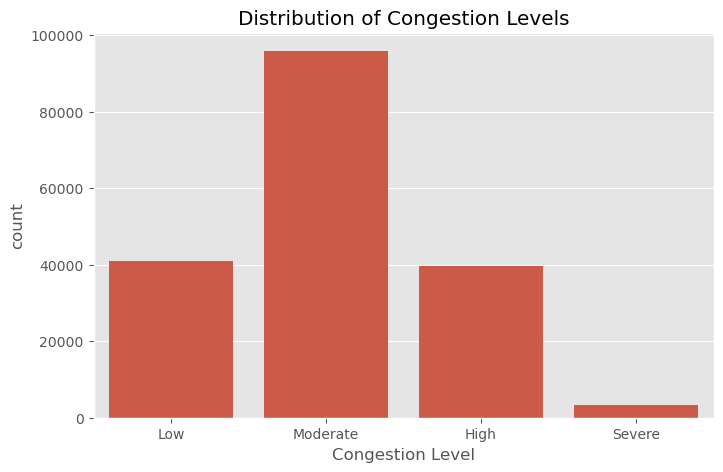

,hour,Traffic Volume
0,0,7477
1,1,7436
2,2,7527
3,3,7570
4,4,7467
...,...,...
19,19,7565
20,20,7497
21,21,7659
22,22,7437


In [79]:
hourly = (
    df.groupby("hour")
      .size()
      .reset_index(name="Traffic Volume")
)
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Congestion Level",
    order=["Low","Moderate","High","Severe"]
)

plt.title("Distribution of Congestion Levels")

plt.show()
hourly

## Findings

Identify which congestion class occurs most frequently.

Discuss whether the dataset appears balanced or imbalanced.

## Findings

State the average vehicle speed and describe the distribution.

Average Speed

In [80]:
average_speed = df["avg_speed_kmh"].mean()

print(f"Average Speed = {average_speed:.2f} km/h")

Average Speed = 55.83 km/h


Histogram

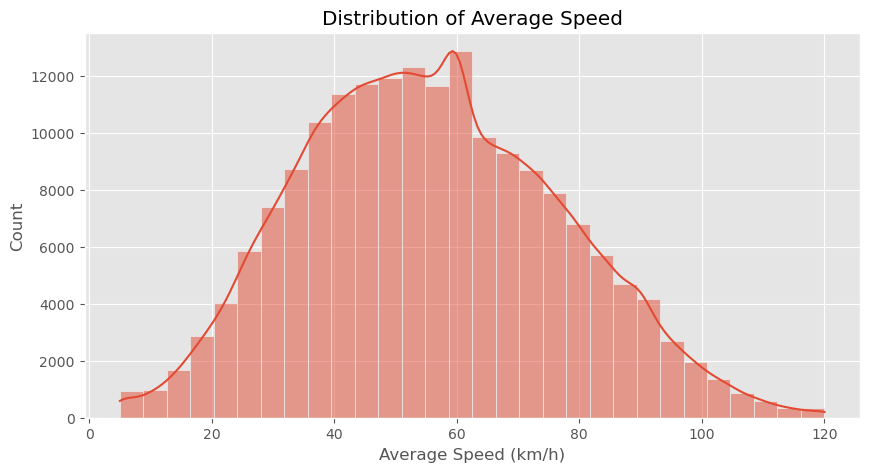

In [81]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["avg_speed_kmh"],
    bins=30,
    kde=True
)

plt.title("Distribution of Average Speed")

plt.xlabel("Average Speed (km/h)")

plt.show()

## Findings

Identify the hours with the highest traffic volume.

These represent the busiest periods of the day.

Peak Traffic Hours

In [82]:
hourly = (
    df.groupby("hour")
      .size()
      .reset_index(name="Traffic Volume")
)

hourly

,hour,Traffic Volume
0,0,7477
1,1,7436
2,2,7527
3,3,7570
4,4,7467
...,...,...
19,19,7565
20,20,7497
21,21,7659
22,22,7437


Visualization

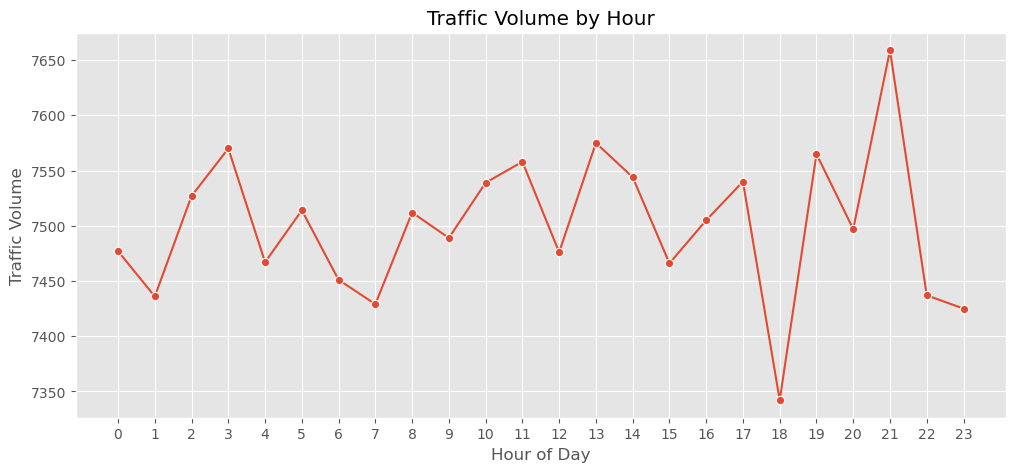

In [83]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=hourly,
    x="hour",
    y="Traffic Volume",
    marker="o"
)

plt.xticks(range(24))

plt.title("Traffic Volume by Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Traffic Volume")

plt.show()

## Findings

Identify the hours with the highest traffic volume.

These represent the busiest periods of the day.

Rush Hour Patterns

In [84]:
rush = (
    df.groupby("hour")["congestion_index"]
      .mean()
      .reset_index()
)

rush

,hour,congestion_index
0,0,36.091521
1,1,32.186001
2,2,28.481387
3,3,24.480462
4,4,20.719847
...,...,...
19,19,52.062842
20,20,48.015006
21,21,44.320629
22,22,40.466317


Visualization

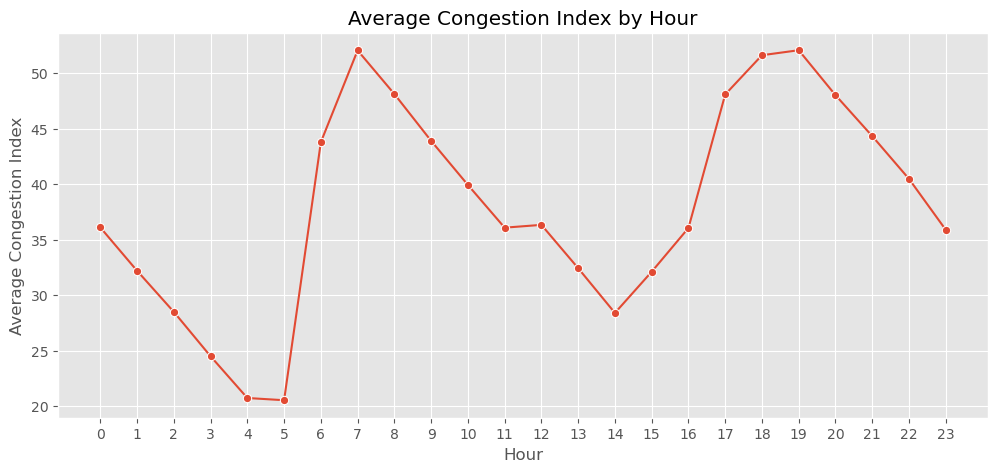

In [85]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=rush,
    x="hour",
    y="congestion_index",
    marker="o"
)

plt.xticks(range(24))

plt.title("Average Congestion Index by Hour")

plt.xlabel("Hour")

plt.ylabel("Average Congestion Index")

plt.show()

## Findings

Discuss how congestion changes throughout the day.

Highlight morning and evening rush-hour periods if they are evident.

 Speed vs Congestion

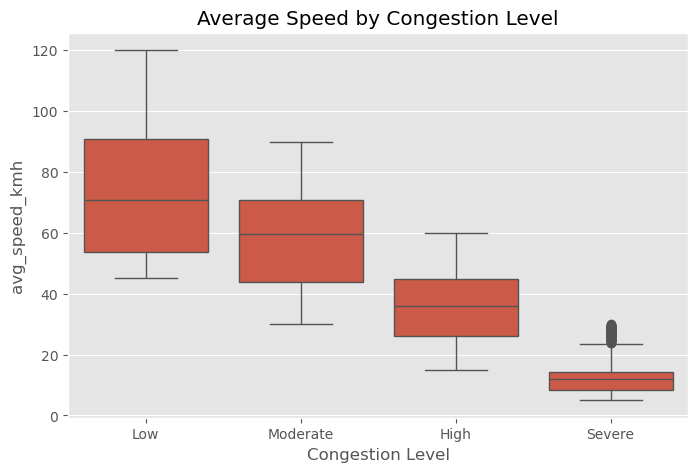

In [86]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Congestion Level",
    y="avg_speed_kmh"
)

plt.title("Average Speed by Congestion Level")

plt.show()

## Findings

Explain how vehicle speed changes as congestion increases.

Traffic Density

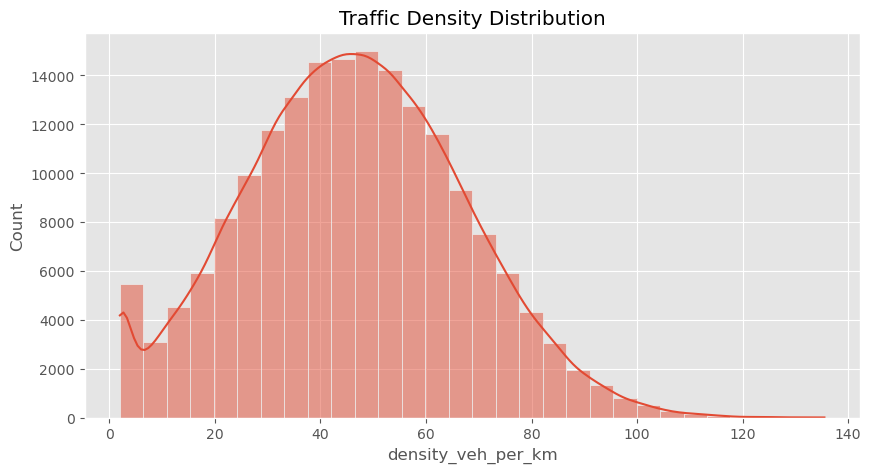

In [87]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["density_veh_per_km"],
    bins=30,
    kde=True
)

plt.title("Traffic Density Distribution")

plt.show()

Incidents by Hour

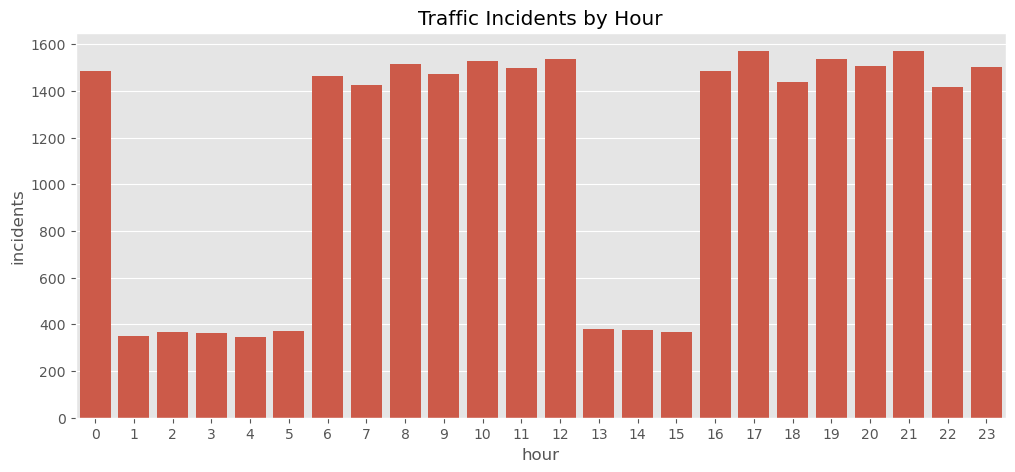

In [88]:
incidents = (
    df.groupby("hour")["incidents"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=incidents,
    x="hour",
    y="incidents"
)

plt.title("Traffic Incidents by Hour")

plt.show()

Correlation Analysis

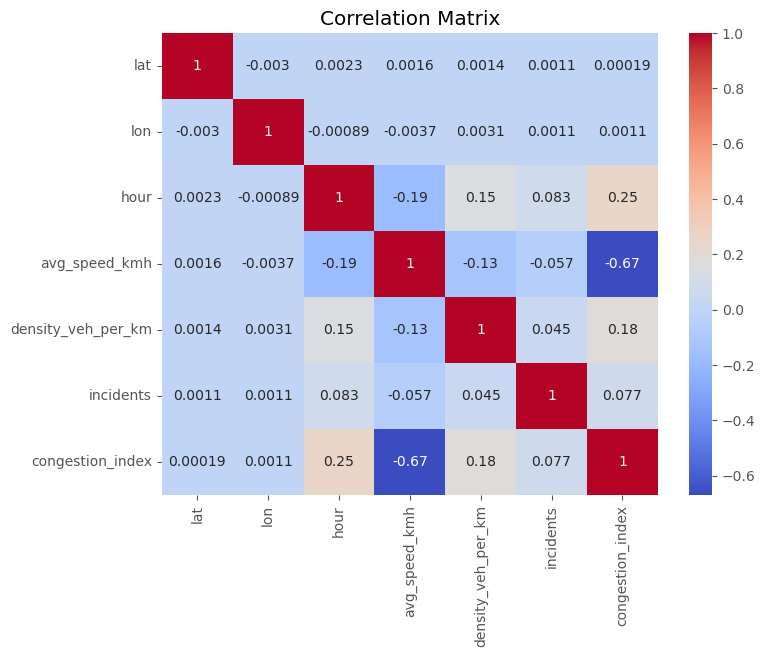

In [89]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Exploratory Data Analysis Summary

## Dataset Overview

- Total records: 180,000
- Total features: 9

## Data Quality

- Missing values: (Fill after running analysis)
- Duplicate records: (Fill after running analysis)

## Traffic Characteristics

- Average speed: XX km/h
- Average congestion index: XX

## Peak Traffic Hours

- Highest traffic volume: XX:00
- Lowest traffic volume: XX:00

## Rush Hour

- Morning peak: XX–XX
- Evening peak: XX–XX

## Key Insights

1. Traffic congestion varies significantly by hour.
2. Higher congestion is associated with lower average speeds.
3. Traffic density and incidents appear to influence congestion.
4. Hour of day is a strong candidate feature for the prediction model.
5. Traffic density, speed, and incidents should be included as input features during model training.

Ensure timestamp is a Datetime

In [90]:
# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Verify
df["timestamp"].head()

0   2024-12-16 14:39:24
1   2025-03-01 15:41:09
2   2024-11-16 11:28:45
3   2025-06-11 11:54:33
4   2024-12-28 07:33:06
Name: timestamp, dtype: datetime64[ns]

Create day_of_week

In [91]:
# Day name
df["day_of_week"] = df["timestamp"].dt.day_name()

# Preview
df[["timestamp", "day_of_week"]].head()

,timestamp,day_of_week
0,2024-12-16 14:39:24,Monday
1,2025-03-01 15:41:09,Saturday
2,2024-11-16 11:28:45,Saturday
3,2025-06-11 11:54:33,Wednesday
4,2024-12-28 07:33:06,Saturday


Create is_weekend

Saturday and Sunday are weekends.

In [92]:
# Weekend indicator
df["is_weekend"] = df["day_of_week"].isin(
    ["Saturday", "Sunday"]
).astype(int)

df[["day_of_week", "is_weekend"]].head()

,day_of_week,is_weekend
0,Monday,0
1,Saturday,1
2,Saturday,1
3,Wednesday,0
4,Saturday,1


Create is_peak_hour

For Lagos traffic, a reasonable starting definition is:

Morning Peak: 7 AM – 10 AM
Evening Peak: 4 PM – 7 PM (16:00–19:00)

In [93]:
def peak_hour(hour):
    if 7 <= hour <= 10:
        return 1
    elif 16 <= hour <= 19:
        return 1
    else:
        return 0

df["is_peak_hour"] = df["hour"].apply(peak_hour)

df[["hour", "is_peak_hour"]].head()

,hour,is_peak_hour
0,14,0
1,15,0
2,11,0
3,11,0
4,7,1


Create time_of_day

Instead of using raw hours, we group them into meaningful periods.

In [94]:
def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["time_of_day"] = df["hour"].apply(time_of_day)

df[["hour", "time_of_day"]].head()

,hour,time_of_day
0,14,Afternoon
1,15,Afternoon
2,11,Morning
3,11,Morning
4,7,Morning


Verify the New Features

In [95]:
df[[
    "timestamp",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_peak_hour",
    "time_of_day"
]].head(10)

,timestamp,hour,day_of_week,is_weekend,is_peak_hour,time_of_day
0,2024-12-16 14:39:24,14,Monday,0,0,Afternoon
1,2025-03-01 15:41:09,15,Saturday,1,0,Afternoon
2,2024-11-16 11:28:45,11,Saturday,1,0,Morning
3,2025-06-11 11:54:33,11,Wednesday,0,0,Morning
4,2024-12-28 07:33:06,7,Saturday,1,1,Morning
5,2025-07-23 07:55:43,7,Wednesday,0,1,Morning
6,2025-07-20 06:39:03,6,Sunday,1,0,Morning
7,2025-05-17 20:11:41,20,Saturday,1,0,Evening
8,2025-04-17 16:36:34,16,Thursday,0,1,Afternoon
9,2025-08-24 07:24:24,7,Sunday,1,1,Morning


Explore the New Features
Distribution of Days

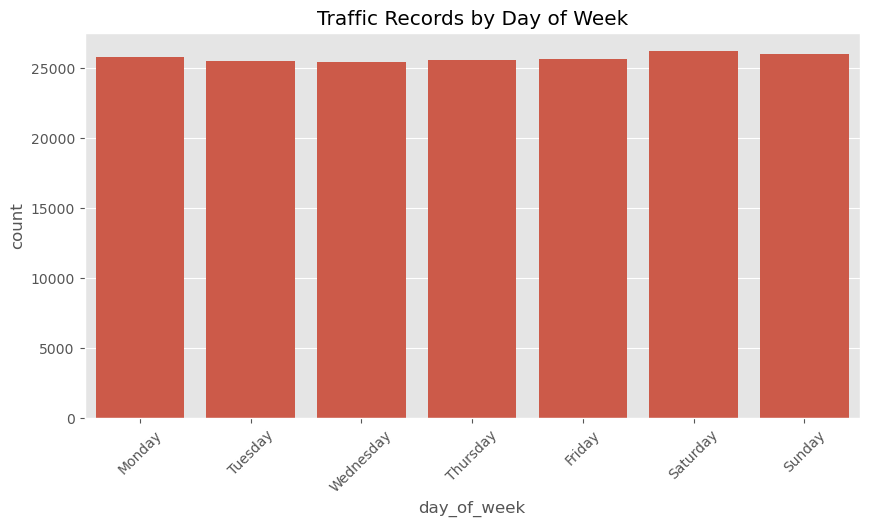

In [96]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="day_of_week",
    order=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]
)

plt.title("Traffic Records by Day of Week")
plt.xticks(rotation=45)
plt.show()

Weekday VS Weekend

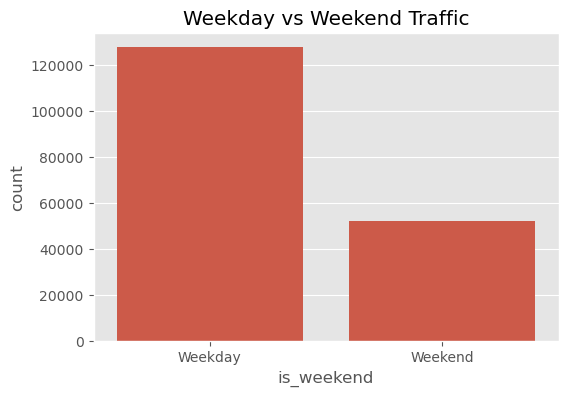

In [97]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="is_weekend"
)

plt.title("Weekday vs Weekend Traffic")

plt.xticks([0,1],["Weekday","Weekend"])

plt.show()

Peak Hour Distribution

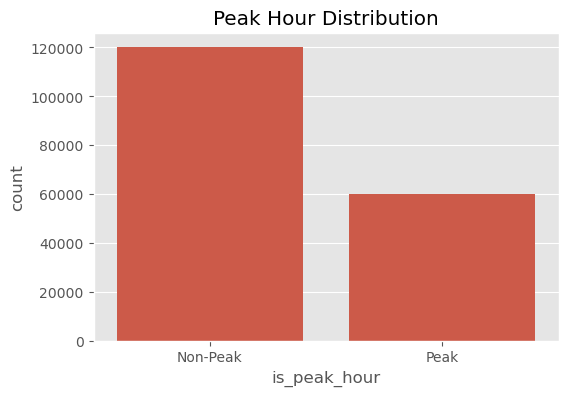

In [98]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="is_peak_hour"
)

plt.title("Peak Hour Distribution")

plt.xticks([0,1],["Non-Peak","Peak"])

plt.show()

Traffic by Time of Day

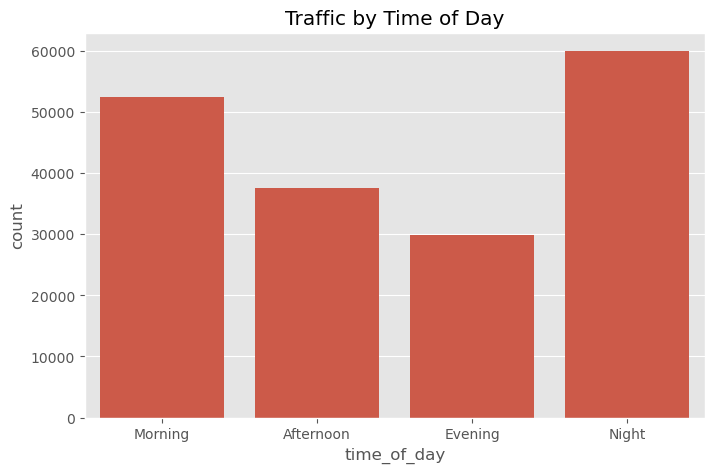

In [99]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="time_of_day",
    order=[
        "Morning",
        "Afternoon",
        "Evening",
        "Night"
    ]
)

plt.title("Traffic by Time of Day")

plt.show()

Save the Enhanced Dataset

This ensures the engineered features are available for model training.

In [100]:
df.to_csv(
    "../../dataset/processed/traffic_engineered.csv",
    index=False
)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


Understand the Target Variable

In [101]:
df["congestion_index"].describe()

count    180000.000000
mean         37.988106
std          17.311724
min           0.000000
25%          26.300000
50%          38.000000
75%          49.500000
max          94.400000
Name: congestion_index, dtype: float64

Visualize

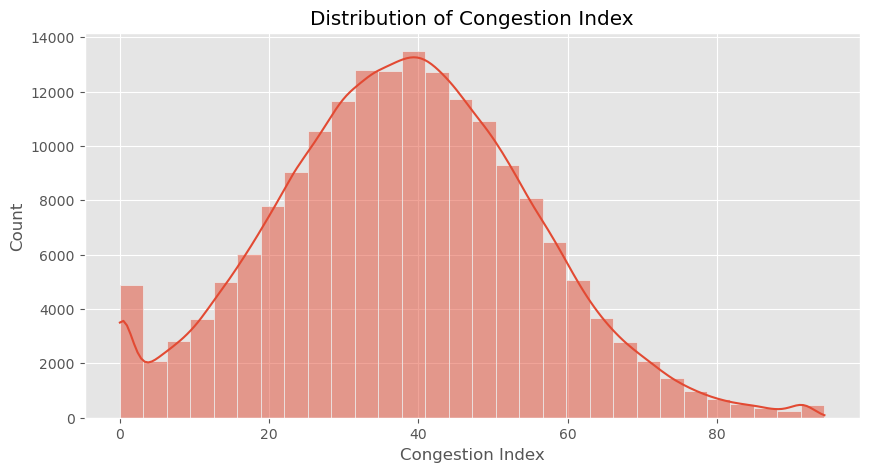

In [102]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["congestion_index"],
    bins=30,
    kde=True
)

plt.title("Distribution of Congestion Index")

plt.xlabel("Congestion Index")

plt.show()

create Congestion Categories

In [103]:
bins = [0, 25, 50, 75, 100]

labels = [
    "Low",
    "Moderate",
    "High",
    "Severe"
]

df["congestion_category"] = pd.cut(
    df["congestion_index"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

Verify the categories

In [104]:
df[["congestion_index", "congestion_category"]].head(10)

,congestion_index,congestion_category
0,20.6,Low
1,23.1,Low
2,42.4,Moderate
3,9.0,Low
4,67.1,High
5,49.5,Moderate
6,35.4,Moderate
7,45.9,Moderate
8,48.1,Moderate
9,65.8,High


Check Class Distrubution

In [105]:
df["congestion_category"].value_counts()

congestion_category
Moderate    95885
Low         40979
High        39718
Severe       3418
Name: count, dtype: int64

Percnetage

In [106]:
(
    df["congestion_category"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

congestion_category
Moderate    53.27
Low         22.77
High        22.07
Severe       1.90
Name: proportion, dtype: float64

Visualization

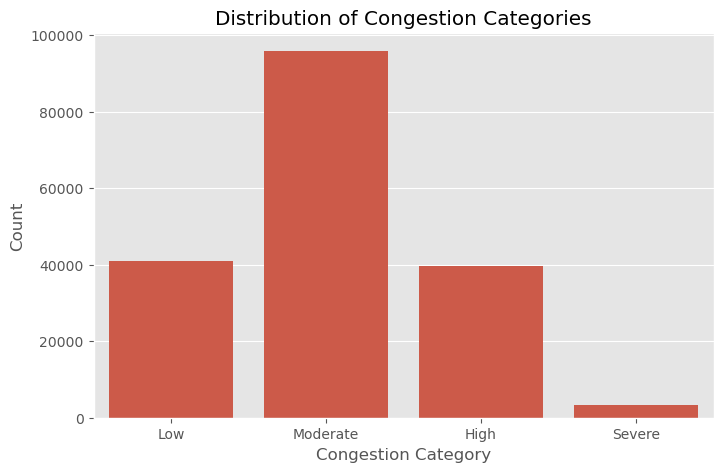

In [107]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="congestion_category",
    order=[
        "Low",
        "Moderate",
        "High",
        "Severe"
    ]
)

plt.title("Distribution of Congestion Categories")

plt.xlabel("Congestion Category")

plt.ylabel("Count")

plt.show()

Check for Class Imbalance

In [108]:
class_distribution = pd.DataFrame({
    "Count": df["congestion_category"].value_counts(),
    "Percentage": (
        df["congestion_category"]
          .value_counts(normalize=True)
          .mul(100)
          .round(2)
    )
})

class_distribution

,Count,Percentage
congestion_category,,
Moderate,95885,53.27
Low,40979,22.77
High,39718,22.07
Severe,3418,1.90


Relationship with Average Speed


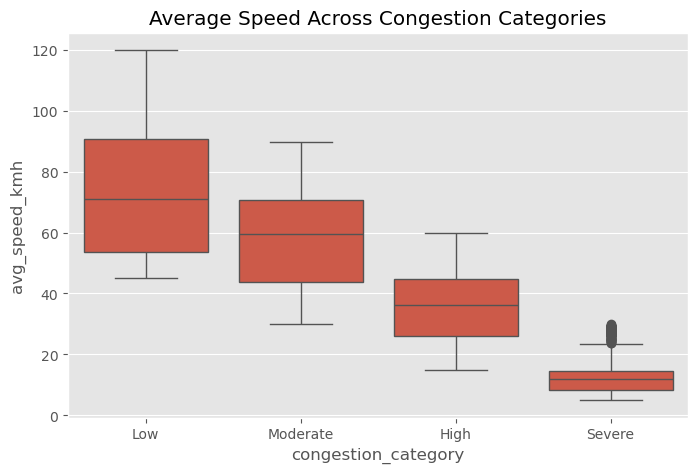

In [109]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="congestion_category",
    y="avg_speed_kmh",
    order=[
        "Low",
        "Moderate",
        "High",
        "Severe"
    ]
)

plt.title("Average Speed Across Congestion Categories")

plt.show()

Relationship with Traffic Density

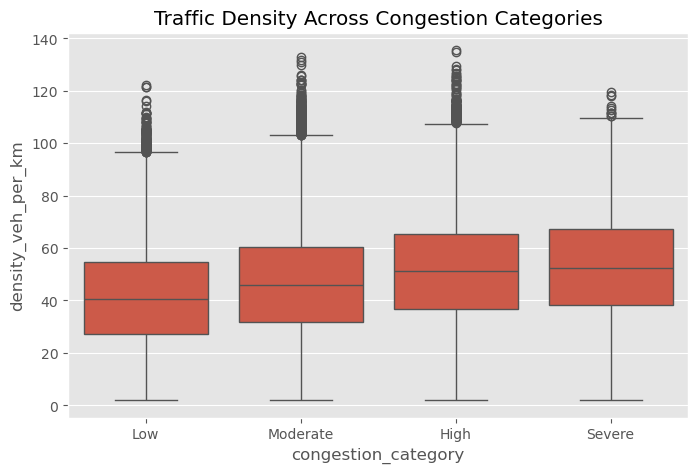

In [110]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="congestion_category",
    y="density_veh_per_km",
    order=[
        "Low",
        "Moderate",
        "High",
        "Severe"
    ]
)

plt.title("Traffic Density Across Congestion Categories")

plt.show()

Relationship with Incidents

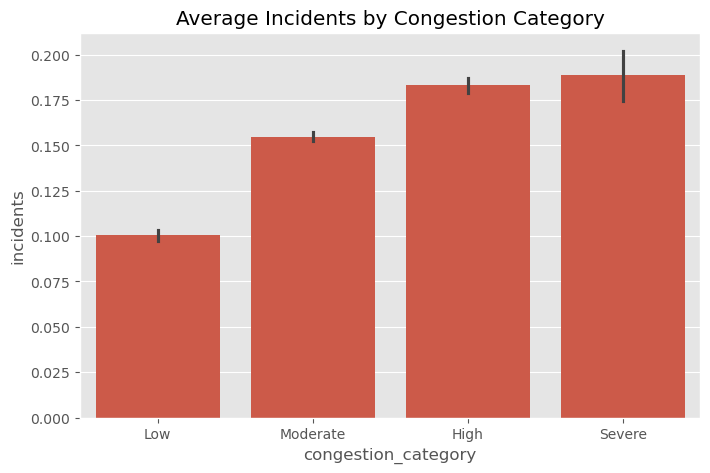

In [111]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="congestion_category",
    y="incidents",
    order=[
        "Low",
        "Moderate",
        "High",
        "Severe"
    ]
)

plt.title("Average Incidents by Congestion Category")

plt.show()

Save the Engineered Dataset

In [112]:
OUTPUT_PATH = "../../dataset/processed/traffic_engineered.csv"

df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Engineered dataset saved successfully!")

Engineered dataset saved successfully!
